# ASP3231 Laboratory 3: Shift, Scale and Combine images

In this week's laboratory we are going to shift, scale and combine images. Doing this is critical to produce combined images where the signal-to-noise is improved, poor quality data is rejected and object fluxes (measured in ADU) that can then be tied to calibrated magnitudes. 

## Prelab Questions

You are expected to read the lab notebook prior to the lab, and the Prelab Questions are designed to prompt you to consider what you have read. This will hopefully prepare you for the lab session and ultimately save time.

#### Question 1: Why do we subtract the background before combining images?
<font color=green>The background contains lots of signal-to-noise. When combining images with noise we would be stacking all these flaws. The algorithm would treat the flaws as real scientific data, which is not ideal. It needs to be subtracted before combining.</font>

#### Question 2: Why is it often safer to take 10 exposures of a science object and combine them instead of taking a single longer exposure?
<font color=green>Doing it this way is safer in the case of outliers. There are all sorts of factors influencing the state of the image between frames, including planes, satellites, comets, changing weather patterns, etc. One plane in a single 100-minute exposure image would render it useless. However if you had split it up into 10 minute increments, that plane might only render one of the 10 minute frames useless, far reducing risk to uncontrollable factors.</font>

#### Question 3: What is an advantage of a median combine over a mean combine?
<font color=green>The median combine's biggest advantage is how it omits outliers. By sorting the data low to high and selecting the middle value, the result is the same regardless of whether the final value is 10 or 100x the middle value. A mean combine might look very different in this case.</font>

#### Question 4: If I want variable i to be the equal to x rounded to the nearest integer, what code should I write?
<font color=green>i = round(x, 0)</font>

#### Question 5: Why is it important to visually inspect images with ds9? What sort of errors could visual inspection catch that may be missed by metadata or statistics? 
<font color=green>Statistics can only take us so far. Knowing how the background numerically affects the image is one thing, but doesn't tell us anything about the shape of the noise. It doesn't tell us the why. Opening images in ds9 and seeing them visually under different scales can tell us a lot more about why we are seeing the results we are. Is it dust donuts? Did someone turn on a light halfway through the exposure? The stats won't encode this information.</font>

#### Quation 6: We will be using for loops quite often in this notebook.  Write a Python program to construct the following pattern, using a loop (with for or while) and just a single print statement (hint, start with 'python'):

p <br>
py <br>
pyt <br>
pyth <br>
pytho <br>
python <br>



In [1]:
# Answer to Q6
target_string = "python"
for i in range(0, len(target_string)):
    current_letter = target_string[i]
    previous_letters = target_string[0:i]
    print(previous_letters + current_letter)


p
py
pyt
pyth
pytho
python


## End of Pre-Lab

# Lab 3. Shift, Scale and Combine images

### By the end of this lab, you should be able to:
- shift images **correctly**
- scale images and understand why you need to scale images
- understand several different methods used for combining images
- provide a combined image with improved signal-to-noise relative to the indiviudal exposures

### Let's begin

**Task 1.** Import all the needed libraries. Can you identify a library or function we didn't use in the previous lab?  

<font color=green>Yes, the astroalign library. Needed to add it to my environment with uv add</font>

In [ ]:
# Import various libraries and some specific functions. Note the additions relative to the previous lab.


import numpy as np
import astropy
import astroalign as aa # Need to run 'uv add astroalign' in project directory
import photutils
import ccdproc
import astropy.io.fits as fits
import matplotlib.pyplot as plt
from ccdproc import CCDData, combiner
from astropy import units as u
from astropy.time import Time
from matplotlib.colors import LogNorm
from photutils.centroids import centroid_com, centroid_2dg, centroid_sources
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry
from photutils.segmentation import detect_sources, deblend_sources, SourceCatalog
from scipy.ndimage import shift

import gc
gc.enable()

**Task 2.** Our starting point is processed R-band images of NGC 3766 that have an exposure time of 120 seconds. Display one of these images in this notebook and use the *vmin and vmax* parameters of function *imshow* so we can see details such as the random noise in the background. Don't forget to label the figure. Use the links below for more help:

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html

https://docs.astropy.org/en/stable/visualization/normalization.html



Set OBSGEO-Y to  2896022.315 from OBSGEO-[LBH].
Set OBSGEO-Z to -3889419.901 from OBSGEO-[LBH]'. [astropy.wcs.wcs]


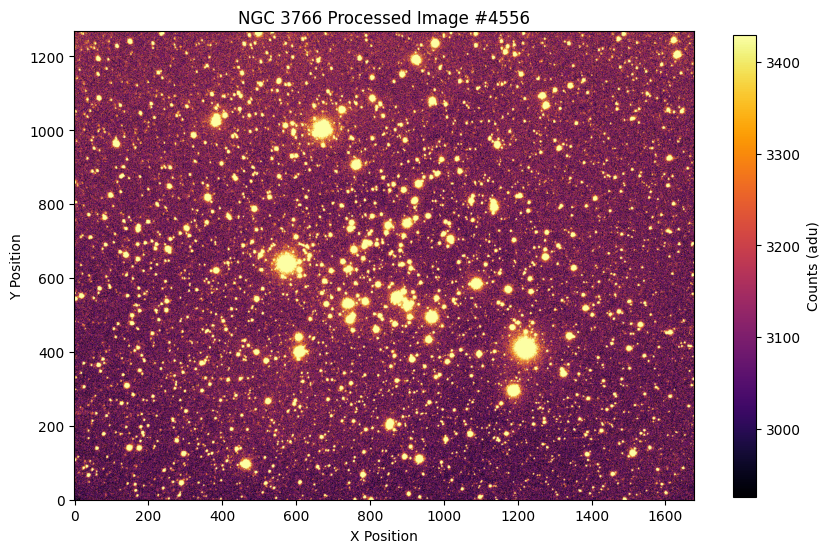

In [3]:
# Load image data using CCDData
file_name = "proc_NGC_3766_R_00004556.fits"
first_image = CCDData.read(file_name)

# Use percentiles
vmin = np.percentile(first_image.data, 5)
vmax = np.percentile(first_image.data, 95)

fig, axes = plt.subplots(1, 1, figsize=(10, 10))

# Labels
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title("NGC 3766 Processed Image #4556")

plt.imshow(first_image, cmap="inferno", vmin=vmin, vmax=vmax, origin="lower")
plt.colorbar(shrink=0.6, label="Counts (adu)")

**Task 3.** Let's create a collection of processed R-band images of NGC 3766 (called images) and load them. <font color=green>Added comments.

In [4]:
images = ccdproc.ImageFileCollection(".",glob_include='proc_NGC_3766_R_*')   # Append all filenames to a list that start with "proc_NGC_3766_R_...."
scim = []                                                                    # This is an empty list - scim
for fn in images.files_filtered(PICTTYPE = 1):
    scim.append(CCDData.read(fn, unit = "adu"))                              # This adds all the raw adu data in each file to a master list called scim
    
    # This code will adds MJD-OBS to the header so it will (later) stop producing error messages
    times = scim[-1].header['DATE-OBS']                                      # Get the time
    t = Time(times, format='isot', scale='utc')                              # Read the time from UTC format
    scim[-1].header['MJD-OBS'] = (float(t.mjd), 'MJD')                       # Add MJD-OBS to header


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
Set OBSGEO-Y to  2896022.315 from OBSGEO-[LBH].
Set OBSGEO-Z to -3889419.901 from OBSGEO-[LBH]'. [astropy.wcs.wcs]
Set OBSGEO-Y to  2896022.315 from OBSGEO-[LBH].
Set OBSGEO-Z to -3889419.901 from OBSGEO-[LBH]'.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


## Shifting

**Task 4.** When we shift our images we do not want overwrite existing images, so we define new image names. Can you use the comments to describe what each line of the following code does?

In [5]:
newname=[]                                     # Initialise an empty list to fill with the new file names
for fn in images.files_filtered(PICTTYPE=1):   # Loop through every filename (PICTTYPE=1 for science images)
    newname.extend(["s"+fn])                   # Add each filename with an "s" in front
print(newname)


['sproc_NGC_3766_R_00004556.fits', 'sproc_NGC_3766_R_00004557.fits', 'sproc_NGC_3766_R_00004558.fits', 'sproc_NGC_3766_R_00004559.fits', 'sproc_NGC_3766_R_00004560.fits', 'sproc_NGC_3766_R_00004641.fits', 'sproc_NGC_3766_R_00004642.fits', 'sproc_NGC_3766_R_00004643.fits', 'sproc_NGC_3766_R_00004644.fits', 'sproc_NGC_3766_R_00004645.fits']


# Don't forget to take notes in this notebook!

**Task 5.** The first image in our list, proc_NGC_3766_R_00004556.fits, has a relatively bright but unsaturated star near x=1190, y=700. Make a copy of this image, subtract the background and then measure the position of the star using centroid_com (centre of mass) <B>and</B> centroid_2dg (2D Guassian). Adapt the code below to measure the position with <B>both</B> methods and comment. 


In [6]:
# Make a copy of the image 
temp=scim[0].copy()
# Subtract the background 
temp=temp-np.ma.median(temp)

starxy = [(1190, 700)]   # Star position 
bs = 39                  # This defines the cutout in each coordinate axis the function will look at. A single number means it will be an n by n square
xc = int(starxy[0][0])   # This extracts just the x-coordinate of the star
yc = int(starxy[0][1])   # The y-coordinate

x1, y1 = centroid_sources(temp, xc, yc, box_size=bs, centroid_func=centroid_com)
print(f"Centroid COM: {x1}, {y1}")

x1, y1 = centroid_sources(temp, xc, yc, box_size=bs, centroid_func=centroid_2dg)
print(f"Centroid Gaussian: {x1}, {y1}")

Centroid COM: [1190.63955666], [702.43701035]
Centroid Gaussian: [1190.34842824], [702.05769604]


<font color=green>They differ by less than a pixel. The Gaussian one being slightly left and up of the centre of mass one indicates that there may be more counts incident on that part of the object.

**Task 6.** Measure the position of the star visually with ds9 and compare that position with what you've measured above. How do the three positions compare? Which position is potentially the most accurate and why? If you had any code warnings, did they (in this instance) result in incorrect positions?


<font color=green>After using ds9 it appears like the centroid is at a slightly higher x and y than listed, however this result is ambiguous due to the object not being perfectly circular. I got about x=1191.9 and y=703.5. The centre of mass centroid is the closest to these values. The Gaussian centroid is slightly off centre, indicating that there may be more counts in the upper left part of the star. The position coordinates initially given were the least accurate as they were likely roughly done by eye in ds9 to pass to the code. Between the COM and Gaussian centroids, we would assume the Gaussian method is more precise as it fits a Gaussian over the actual counts of the pixels, rather than just forming a mass centre based on bright pixels. However, if the pixels are saturated, then there would not be a Gaussian fit over the star, and the COM would be more efficient. I am going to use the COM method for all my stars to avoid having to check for saturation for each star, and the difference between them is evidently negligible.

**Task 7.** Measure the approximate position of this star in all of the processed images of NGC 3766 using ds9 and then modify the code below to produce refined positions with centroid_com or centroid_2dg. We will use this star's precise position to determine how much images should be shifted in x and y before combining. Comment the code as you go and cross check the positions seem consistent with what you measured with ds9.


In [7]:
starxy = []

"""
Change the centre 'guess' for each star based on ds9 -> sky is moving, so it will change
"""

#proc_NGC_3766_R_00004556.fits
starxy.append((1192,703))        # Initial estimate of star positon
#proc_NGC_3766_R_00004557.fits
starxy.append((1192,703))        
#proc_NGC_3766_R_00004558.fits
starxy.append((1192,703))        
#proc_NGC_3766_R_00004559.fits
starxy.append((1192,703))        
#proc_NGC_3766_R_00004560.fits
starxy.append((1192,703))        
#proc_NGC_3766_R_00004641.fits
starxy.append((1187,697))        # Change from here - images were taken later and sky has moved
#proc_NGC_3766_R_00004642.fits
starxy.append((1187,697))        
#proc_NGC_3766_R_00004643.fits
starxy.append((1187,697))        
#proc_NGC_3766_R_00004644.fits
starxy.append((1187,697))        
#proc_NGC_3766_R_00004645.fits
starxy.append((1187,697))       

# Step through the images and produce a list of positions 
newstarxy=[]
for idx, thisimage in enumerate(scim): 
    # This is the same code as for the single image
    xc = int(starxy[idx][0])
    yc = int(starxy[idx][1])
    bs = 39

    temp=scim[idx].copy() # Make a copy
    temp=temp-np.ma.median(temp) # Subtract background

    # Use centroid_com for each star and append
    x1, y1 = centroid_sources(temp, xc, yc, box_size=bs, centroid_func=centroid_com)
    newstarxy.append((x1, y1))

print(newstarxy)



[(array([1190.56559429]), array([702.32919439])), (array([1190.32619253]), array([702.17576579])), (array([1190.29802022]), array([702.23858239])), (array([1190.31452654]), array([702.21695473])), (array([1190.45535298]), array([702.1342719])), (array([1185.076021]), array([696.55257708])), (array([1184.89477261]), array([696.85837427])), (array([1184.83374613]), array([696.53864682])), (array([1185.1655692]), array([696.76921512])), (array([1184.84007559]), array([696.9210825]))]


<font color=green>Positions are consistent with initial guesses using centroid centre of mass. There is a change between the first 5 images and the second 5 images, which were taken much later. As a result, the sky has moved and the centre guess had to be adjusted accordingly using ds9.

**Task 8.** Determine the integer offsets that need to be applied to shift the star to the same x-y as those given in the first image. The first image has shifts of 0,0 by definition. 

**Hints** When you produce your list of shifts you need to shift the current image to the reference image. For example, if your star is at 100,100 in the reference image and 90,95 in the current image, you need to apply shifts of +10, +5 (not -10, -5). Also, the np.rint function could be useful to implement integer shifts. 


In [8]:
shifts=[]                                                                # Blank shifts list

for idx, xy in enumerate(newstarxy):                                     # Step through list of xy coords
    x_diff = newstarxy[0][0]-newstarxy[idx][0]                           # Subtract the image x position from the reference x position
    y_diff = newstarxy[0][1]-newstarxy[idx][1]                           # Subtract the image y position from the reference y position   
    shifts.append((x_diff, y_diff))                                      # Append the x and y differences to the list

shifts = np.rint(shifts) # np.rint converts every number in shifts to an integer efficiently
         
print(shifts) # Shifts represents how many pixels to add to each frame to align them properly


[[[0.]
  [0.]]

 [[0.]
  [0.]]

 [[0.]
  [0.]]

 [[0.]
  [0.]]

 [[0.]
  [0.]]

 [[5.]
  [6.]]

 [[6.]
  [5.]]

 [[6.]
  [6.]]

 [[5.]
  [6.]]

 [[6.]
  [5.]]]


**Task 9.** Once you are happy with the shifts, apply them to the images and write out the shifted images to FITS files. While we are at it, we will subtract the sky background too (which will come in handy later). 

In [9]:
# Loop through the enumerated (numbered) list of images
for idx, thisimage in enumerate(scim): 
    yxshifts=(shifts[idx][1], shifts[idx][0]) # A 2D array of the pixel shifts, in row-column (y-x) format for Python

    # The shift() function will physically shift all the entries in an array
    # We are passing the current image, the shift amount (2D), order=0 means nearest-neighbour interpolation, 
    # cval = -1000 indicates what to fill in regions outside the boundary when using 'constant' mode
    #
    # We are also subtracting the background in the same line before passing the entire file to CCDData
    temp = CCDData(shift(scim[idx], yxshifts, order=0, mode='constant', cval=-1000)-np.ma.median(scim[idx]), unit="adu")

    # Apply the appropriate header information to the new file
    temp.header = scim[idx].header

    # Write the new file using the new names list we made earlier
    temp.write(newname[idx], overwrite=True)
    


<font color=green>This code is quite succinctly written so I have tried to elaborate on my code comments. The main part is that it applies the shifts to the data, subtracts the background, and passes the data through CCDData all in one line. Then ir writes out the new image files.

**Task 10.** Use ds9 to display these images, and check they have been successfully registered. A simple command line for this is: 

ds9 sproc_NGC_3766_R* &

The "blink frames" option in the frame menu could prove useful. Once you are happy with these images, we can move onto the step to scaling the images before combining.


<font color=green>The images all look perfectly aligned with each other now. The first 5 images look almost the same and the next 5 images appear visually different (due to time difference) but the objects are all now in the same location

## Important note about reference images

When shifting images it makes sense to use the same reference image for all your bands (B, V, R or I). That way each object will have the same x-y coordinates in all your bands, and you can use one catalogue of object pixel coordinates to measure photometry in all your bands. This will also simplify the creation of colour images later in the semester. 

**However** when scaling your images you should use a different reference image for each band (i.e. a B-band reference for the B-band scaling) as the fluxes and magnitudes of objects vary from band to band.

## Scaling

**Task 11.** Create a collection of shifted images of NGC 3766 (called images) and read these images into scim. 

In [10]:
images = ccdproc.ImageFileCollection(".",glob_include='sproc_NGC_3766_R_*')  # Append all filenames to a list that start with "sproc_NGC_3766_R_...."
scim = []                                                                    # This is an empty list - scim
for fn in images.files_filtered(PICTTYPE=1):
    scim.append(CCDData.read(fn, unit = "adu"))                              # This adds all the raw adu data in each file to a master list called scim

INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
Set OBSGEO-Y to  2896022.315 from OBSGEO-[LBH].
Set OBSGEO-Z to -3889419.901 from OBSGEO-[LBH]'. [astropy.wcs.wcs]
Set OBSGEO-Y to  2896022.315 from OBSGEO-[LBH].
Set OBSGEO-Z to -3889419.901 from OBSGEO-[LBH]'.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the

INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader inste

**Task 12.** To determine scalings, we need to identify bright unsaturated stars that are in all the images, and we will use the fluxes of these stars to see how the images have been dimmed (relative to a reference image) by passing clouds and scattering/absorption of light by our atmosphere.

Below we have defined a list of three stars, but used the reference star we used earlier for all three sets of coordinates. Identify two additional unsaturated bright stars and use these in the following code.

In [11]:
# Three positions using the same star 3 times.
positions = [(212.0,449.0), (212.0,449.0), (212.0,449.0)]   #x-y notation

# Create an updated list of positions using 3 difference stars
positions = [(212.0,449.0), (594.0,758.0), (1263.0,940.0)]   #x-y notation

# This creates circular apertures over each star in our array with a radius of 20 pixels.
apertures = CircularAperture(positions, r=20.0)


**Task 13.** We can measure the counts of the three stars in the first image, and print them to the screen. This is aperture photometry, so it's adding up the flux (above the background) within some radius. Run the following code cell.

In [12]:
phot_table = aperture_photometry(scim[0], apertures)
print(phot_table)

 id xcenter ycenter    aperture_sum   
                           adu        
--- ------- ------- ------------------
  1   212.0   449.0 183583.14883677277
  2   594.0   758.0    233645.60640736
  3  1263.0   940.0 128598.97669160001


**Task 14.** Let's now do determine the counts (fluxes) for these stars in all of the images. Don't forget to use comments to describe what the following code is doing (and why it's being done).


In [13]:
phot_tables=[]
# Loop through the numbered list of image data
for idx, thisimage in enumerate(scim):
    # The phot_tables list will be filled with sets of apertures for each different image
    phot_tables.extend([aperture_photometry(thisimage, apertures)])      
    print(idx, phot_tables[idx])

0  id xcenter ycenter    aperture_sum   
                           adu        
--- ------- ------- ------------------
  1   212.0   449.0 183583.14883677277
  2   594.0   758.0    233645.60640736
  3  1263.0   940.0 128598.97669160001
1  id xcenter ycenter    aperture_sum   
                           adu        
--- ------- ------- ------------------
  1   212.0   449.0 183693.88122642104
  2   594.0   758.0  233498.4415795801
  3  1263.0   940.0 138520.61255909424
2  id xcenter ycenter    aperture_sum   
                           adu        
--- ------- ------- ------------------
  1   212.0   449.0 176338.60515939095
  2   594.0   758.0  239487.6865349772
  3  1263.0   940.0 130523.09611235358
3  id xcenter ycenter    aperture_sum   
                           adu        
--- ------- ------- ------------------
  1   212.0   449.0  177153.4566141577
  2   594.0   758.0 229568.52352740674
  3  1263.0   940.0  137749.4924678087
4  id xcenter ycenter    aperture_sum   
               

**Task 15.** To print the fluxes (no coordinates) for the stars in the first image (index=0), we can use the following command.

In [14]:
print(phot_tables[0]['aperture_sum'])

[183583.14883677 233645.60640736 128598.9766916 ] adu


**Task 16.** Which image should we use as our reference image? While the first image (index zero) is easiest, is it a suitable reference image? What properties should a good reference image have?

<font color=green>A good reference image will have the clearest image possible. Looking in ds9, the first 5 images are much more clear than the second 5. I decided still to choose the first image as all the stars I compared looked quite clear, and it is not significantly different to the other four.

**Task 17.** What is the following series of commands doing? 

In [15]:
refidx=0 # The index of our reference image.

# Loop through the numbered list of image data
for idx, thisimage in enumerate(scim): 

    # This line looks at the list of apertures in the reference image and divides it by the apertures in the i-th image
    normal_difference = phot_tables[refidx]['aperture_sum']/phot_tables[idx]['aperture_sum']

    # Here we will take the median combine of the differences to achieve the relative scaling of each image compared to the reference.
    median_scaling = np.ma.median(normal_difference)
    
    print(f"Image {idx} --- Individual aperture scaling: {normal_difference}.\nMedian image scale compared to reference: {median_scaling:.6f}.\n")

Image 0 --- Individual aperture scaling: [1. 1. 1.].
Median image scale compared to reference: 1.000000.

Image 1 --- Individual aperture scaling: [0.99939719 1.00063026 0.9283743 ].
Median image scale compared to reference: 0.999397.

Image 2 --- Individual aperture scaling: [1.04108314 0.97560593 0.9852584 ].
Median image scale compared to reference: 0.985258.

Image 3 --- Individual aperture scaling: [1.03629448 1.01775976 0.93357133].
Median image scale compared to reference: 1.017760.

Image 4 --- Individual aperture scaling: [1.0472978  0.98956502 0.93460159].
Median image scale compared to reference: 0.989565.

Image 5 --- Individual aperture scaling: [1.25295016 1.1522228  1.04661802].
Median image scale compared to reference: 1.152223.

Image 6 --- Individual aperture scaling: [1.36112297 1.19999012 1.04300327].
Median image scale compared to reference: 1.199990.

Image 7 --- Individual aperture scaling: [1.28669273 1.08129607 0.98968825].
Median image scale compared to refere

<font color=green> We can clearly see for each image that there is a very small scaling that needs to be applied to the images. Also, the second five images are consistently less clear than the first. The first image is 1.0, as expected since it is itself the reference image.

# Combine

**Task 18.**  Happy with the scalings? How have you confirmed that they make sense (and is this documented here)? If you are happy with the scalings then let's combine the images together using two methods - averaging and median combine. Comment on the following code cell; what does minmax clip do?

In [16]:
# Get a list of image names and add all the data to the scim variable. Standard stuff by now
images = ccdproc.ImageFileCollection(".",glob_include = 'sproc_NGC_3766_R*')
scim = [CCDData.read(fn) for fn in images.files_filtered()]

# Loop through the numbered list of data
for idx, thisimage in enumerate(scim): 
    # This line saves the median value of the scalings of each aperture. This is the same code as in the previous code cell but written more succinctly.
    m = np.ma.median(phot_tables[refidx]['aperture_sum'] / phot_tables[idx]['aperture_sum'])
    print(m)

    # Here we will multiply all the data in each image by the scale value (in correct units)
    scim[idx] = scim[idx].multiply(m * u.adu)

"""
The minmax_clip_min parameter defines a count value below which the combiner will ignore, removing improperly exposed images.
"""

# This does the average (mean) combine of the images and writes it to a file. The parameters are quite self explanatory - passing the data array, specifying the average method, casting values as floats, and specifying the minimum clip.
sci_average = ccdproc.combine(scim, method = 'average',dtype = np.float32, 
                              minmax_clip = True, minmax_clip_min = -500)
sci_average.write("NGC_3766_R_average.fits", overwrite=True)

# This line is exactly the same as the previous line, however this does the median rather than the average.
sci_median = ccdproc.combine(scim, method = 'median',dtype = np.float32, 
                             minmax_clip = True, minmax_clip_min = -500)
sci_median.write("NGC_3766_R_median.fits", overwrite=True)

"""
Clear the scim variable from temporary memory as it's no longer needed
"""
del(scim)
collected = gc.collect()
print('Check garbage collection', collected)

Set OBSGEO-Y to  2896022.315 from OBSGEO-[LBH].
Set OBSGEO-Z to -3889419.901 from OBSGEO-[LBH]'. [astropy.wcs.wcs]
Set OBSGEO-Y to  2896022.315 from OBSGEO-[LBH].
Set OBSGEO-Z to -3889419.901 from OBSGEO-[LBH]'.


1.0
0.9993971906472389
0.9852583988729681
1.0177597643496912
0.9895650239388054
1.1522227964436673
1.199990115626693
1.081296070379404
1.2079250919236042
1.1904843736351405
Check garbage collection 64


**Task 19.**  How do the combined images visually compare using ds9? What are two similarities and what is one difference? 


<font color=green>

**Similarities:**
- All objects are in the same positions
- Both images look relatively uniform and free of noise

**Differences:**
- The average image does not remove many of the hot pixels, whereas these are absent from the median

</font>

**Task 20.** How does the photometry of the final product compare with the reference photometry? How do the statistics compare? Below we provide a sample code to print out the stats for the average stacked image. Perform the similar task for the median stacked image.

In [17]:
print('--- Average combine stats ---')
# Get the photo table of the average image
phot_table_average = aperture_photometry(sci_average, apertures)
# Print out median pixel value
print('Median pixel value:', np.ma.median(sci_average))

# Photometry code to modify 
print(phot_table_average)
# Compare to reference apertures
print(phot_tables[refidx]['aperture_sum']/phot_table_average['aperture_sum'])

# Do the same for median
print('\n\n--- Median combine stats ---')
phot_table_median = aperture_photometry(sci_median, apertures)
print('Median pixel value:', np.ma.median(sci_median))
print(phot_table_median)
print(phot_tables[refidx]['aperture_sum']/phot_table_median['aperture_sum'])



--- Average combine stats ---
Median pixel value: -7.915381
 id xcenter ycenter    aperture_sum     aperture_sum_err 
                           adu2               adu2       
--- ------- ------- ------------------ ------------------
  1   212.0   449.0 170995.17346162972  2645.892005109419
  2   594.0   758.0 233847.97641753446 3110.6450620273417
  3  1263.0   940.0 138171.67987755846  2057.005582874086
[1.07361597 0.99913461 0.93071878] 1 / adu


--- Median combine stats ---
Median pixel value: -7.597169
 id xcenter ycenter    aperture_sum    aperture_sum_err 
                           adu2              adu2       
--- ------- ------- ----------------- ------------------
  1   212.0   449.0 166734.4225212506 2015.5923925396796
  2   594.0   758.0 231671.8952846768 2139.3366038131876
  3  1263.0   940.0 137849.5387571087 1821.6982037741218
[1.10105128 1.00851942 0.93289378] 1 / adu


<font color=green>Our observations above can be represented here as well. We see that the average image is overall a big darker than the median image, however the aperture sums in the average image are overall slightly brighter.

# Automated alignment of images

There are automated alignment tools for astronomical images affiliated with astropy that can handle x-y shifts and rotations. However, one needs to take care when using them as they can run into trouble. For example, they can accidentally detect hot pixels as objects. Also, they interpolate when shifting images, which can blur data across pixels (which can be a plus or a minus depending on what you are doing). 

Finally, this code loads in all the images and aligns them, which uses memory. An alternative approach is to load the reference image, and then load one image at a time to align, so only two images are in memory.

**Task 21.**  Load the processed science images and run automated image alignment code below. 


In [18]:
images = ccdproc.ImageFileCollection(".",glob_include='proc_NGC_3766_R*') # Load all the image file names as a list
scim = [CCDData.read(fn) for fn in images.files_filtered(PICTTYPE=1)]        # Save all the image data in a master list called scim
newname=[]                                                                   # Initialise the empty array of new file names
for fn in images.files_filtered(PICTTYPE=1):                                 # Loop through every file name
    newname.extend(["aa"+fn])                                                 # Add "aa" to the start and append it to the new list
print(newname)                                                               # Print the new list

Set OBSGEO-Y to  2896022.315 from OBSGEO-[LBH].
Set OBSGEO-Z to -3889419.901 from OBSGEO-[LBH]'. [astropy.wcs.wcs]
Set OBSGEO-Y to  2896022.315 from OBSGEO-[LBH].
Set OBSGEO-Z to -3889419.901 from OBSGEO-[LBH]'.


['aaproc_NGC_3766_R_00004556.fits', 'aaproc_NGC_3766_R_00004557.fits', 'aaproc_NGC_3766_R_00004558.fits', 'aaproc_NGC_3766_R_00004559.fits', 'aaproc_NGC_3766_R_00004560.fits', 'aaproc_NGC_3766_R_00004641.fits', 'aaproc_NGC_3766_R_00004642.fits', 'aaproc_NGC_3766_R_00004643.fits', 'aaproc_NGC_3766_R_00004644.fits', 'aaproc_NGC_3766_R_00004645.fits']


In [19]:
redfidx=0 # Set the reference image to zero

Reference and example image defined
Image alignment determined


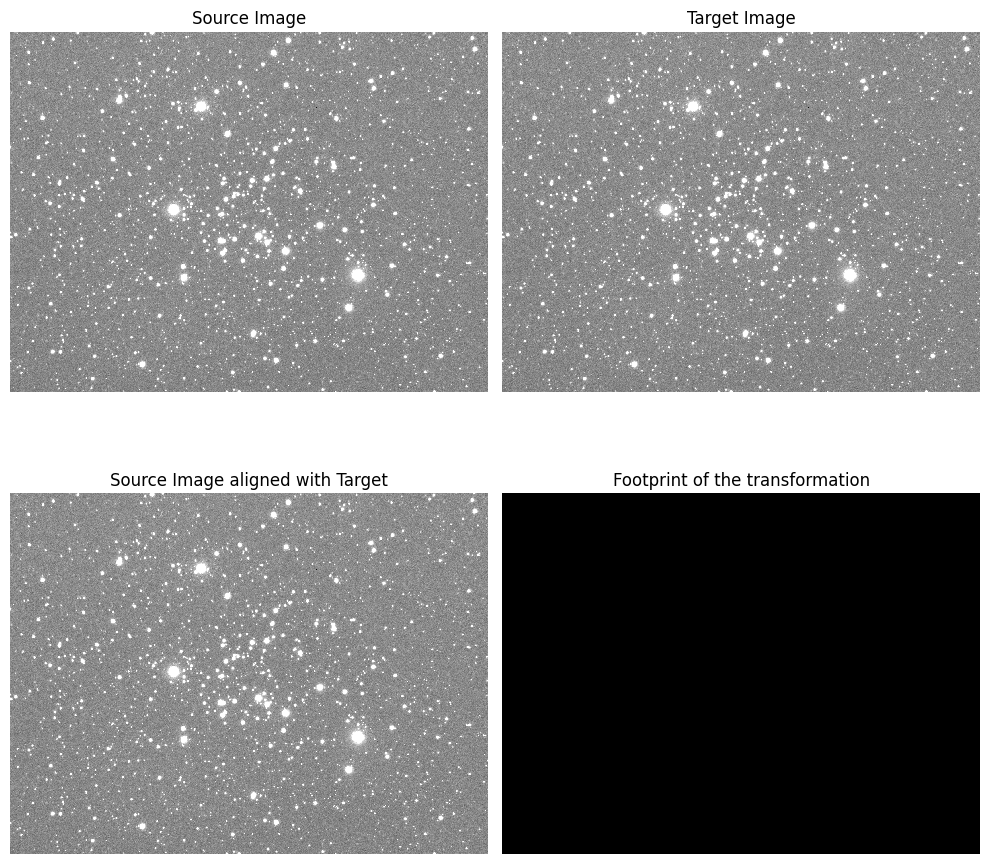

aaproc_NGC_3766_R_00004556.fits
Reference and example image defined
Image alignment determined


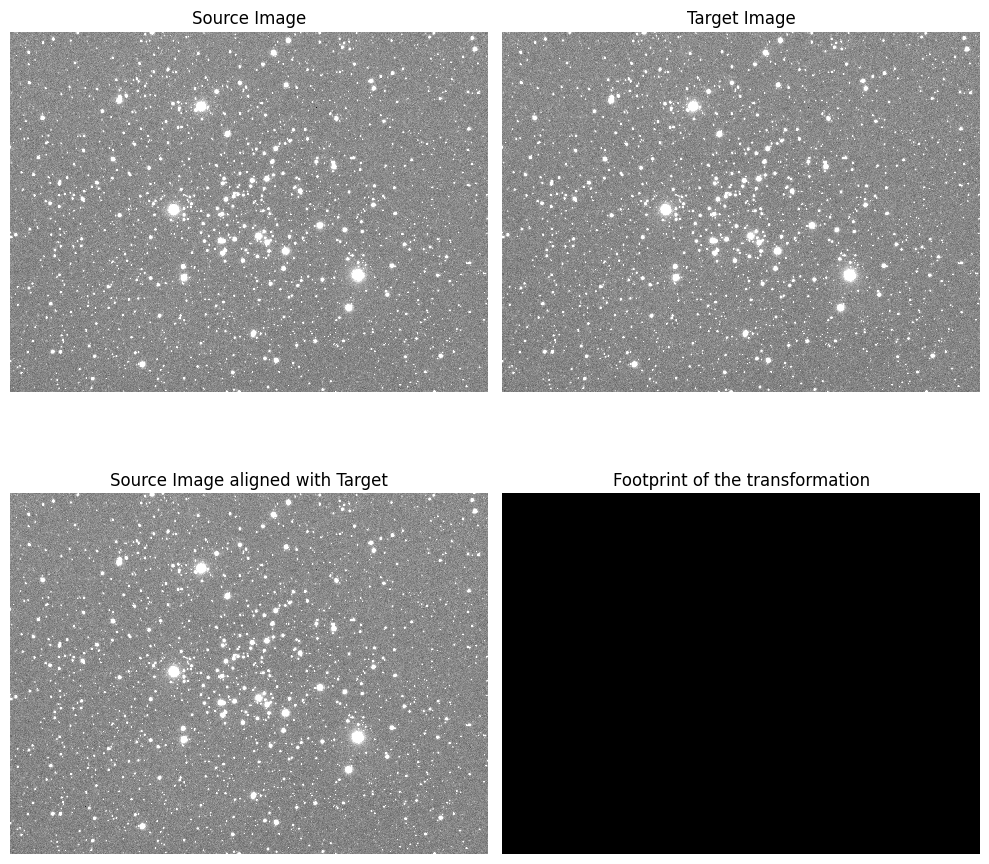

aaproc_NGC_3766_R_00004557.fits
Reference and example image defined
Image alignment determined


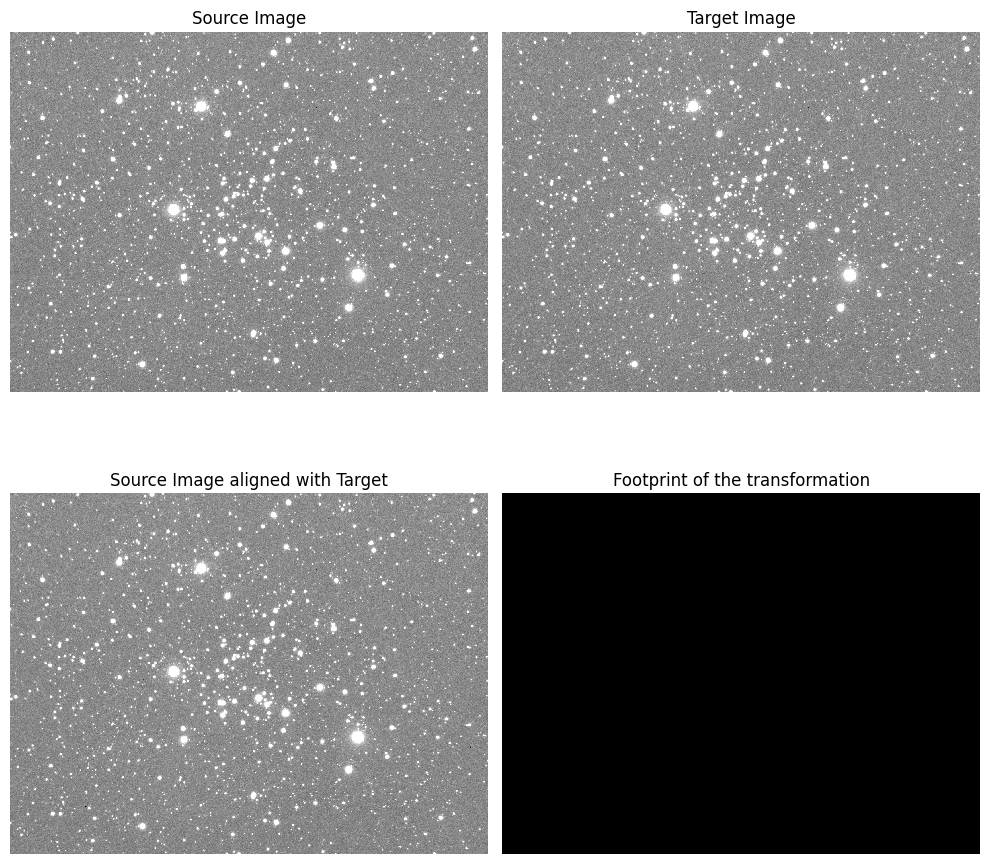

aaproc_NGC_3766_R_00004558.fits
Reference and example image defined
Image alignment determined


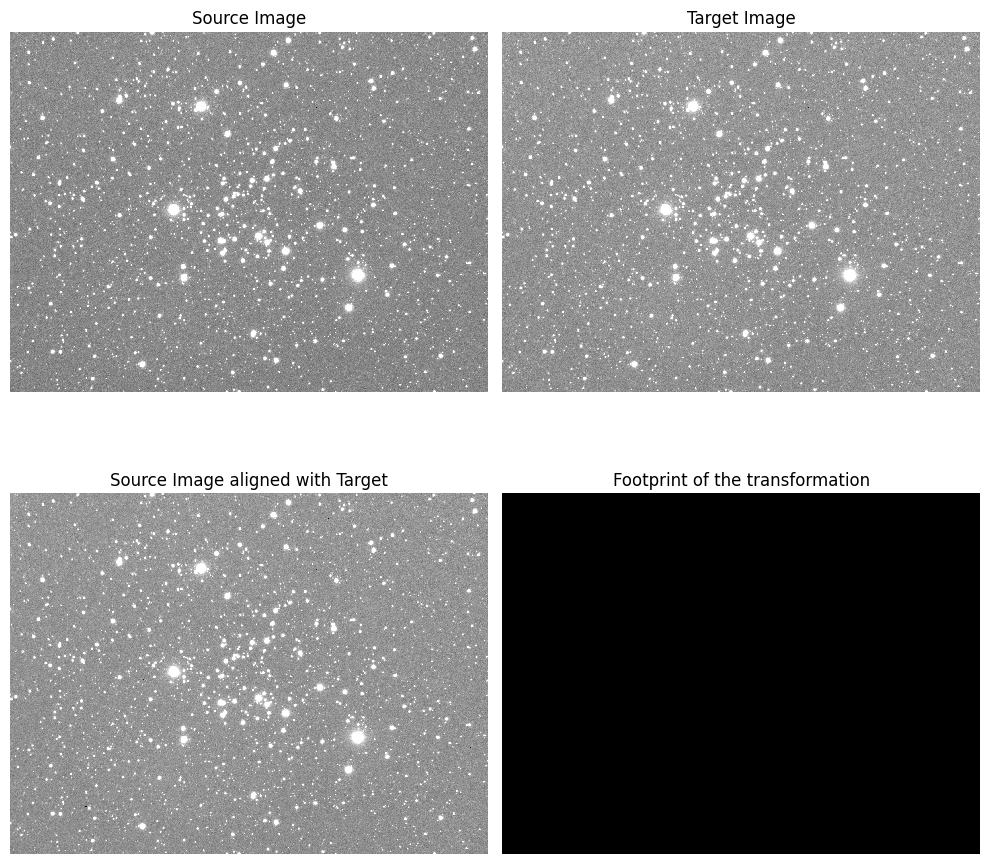

aaproc_NGC_3766_R_00004559.fits
Reference and example image defined
Image alignment determined


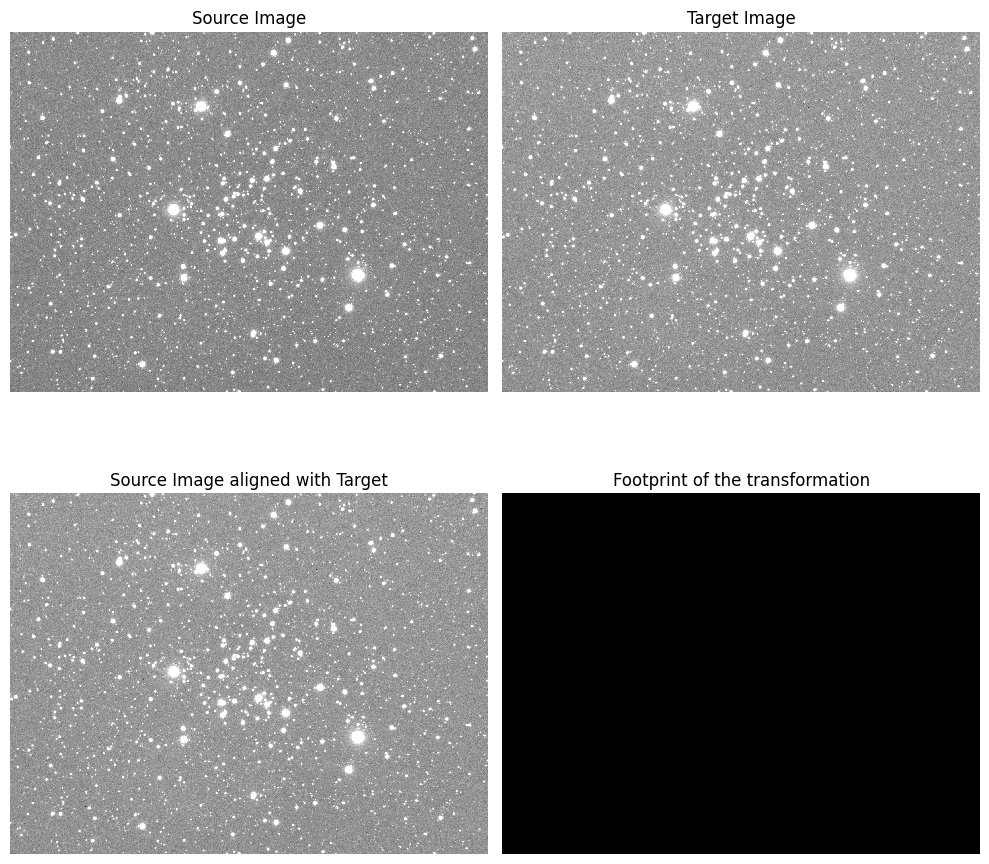

aaproc_NGC_3766_R_00004560.fits
Reference and example image defined
Image alignment determined


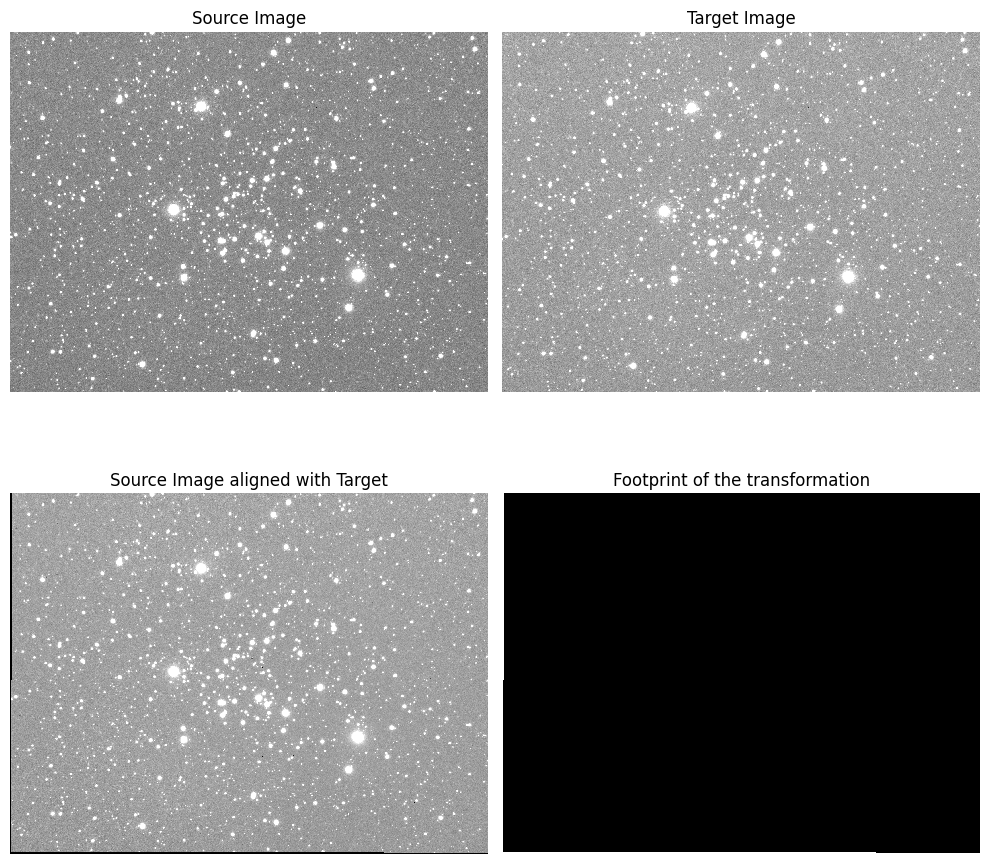

aaproc_NGC_3766_R_00004641.fits
Reference and example image defined
Image alignment determined


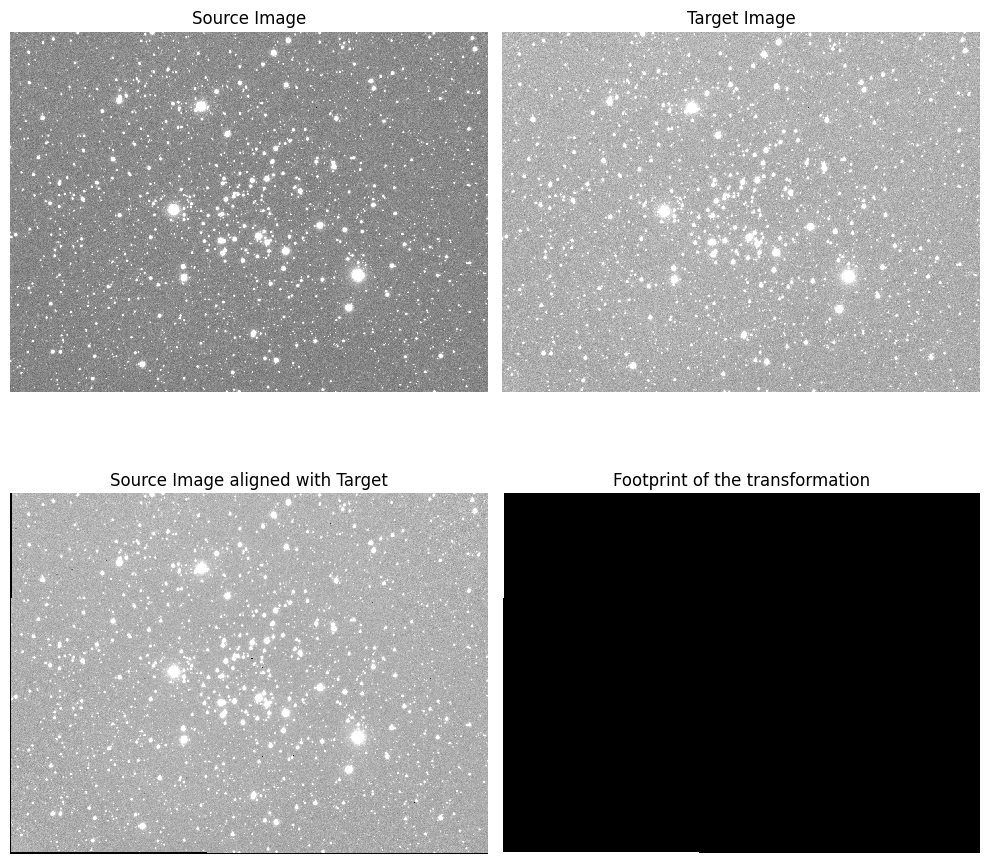

aaproc_NGC_3766_R_00004642.fits
Reference and example image defined
Image alignment determined


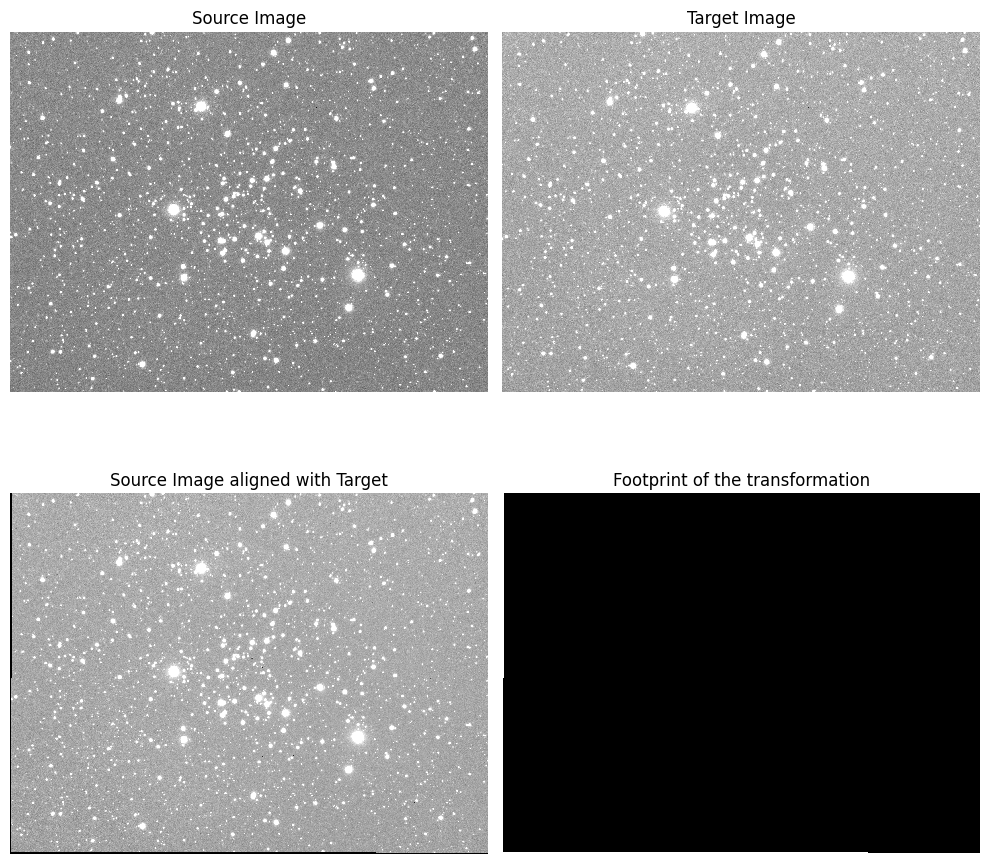

aaproc_NGC_3766_R_00004643.fits
Reference and example image defined
Image alignment determined


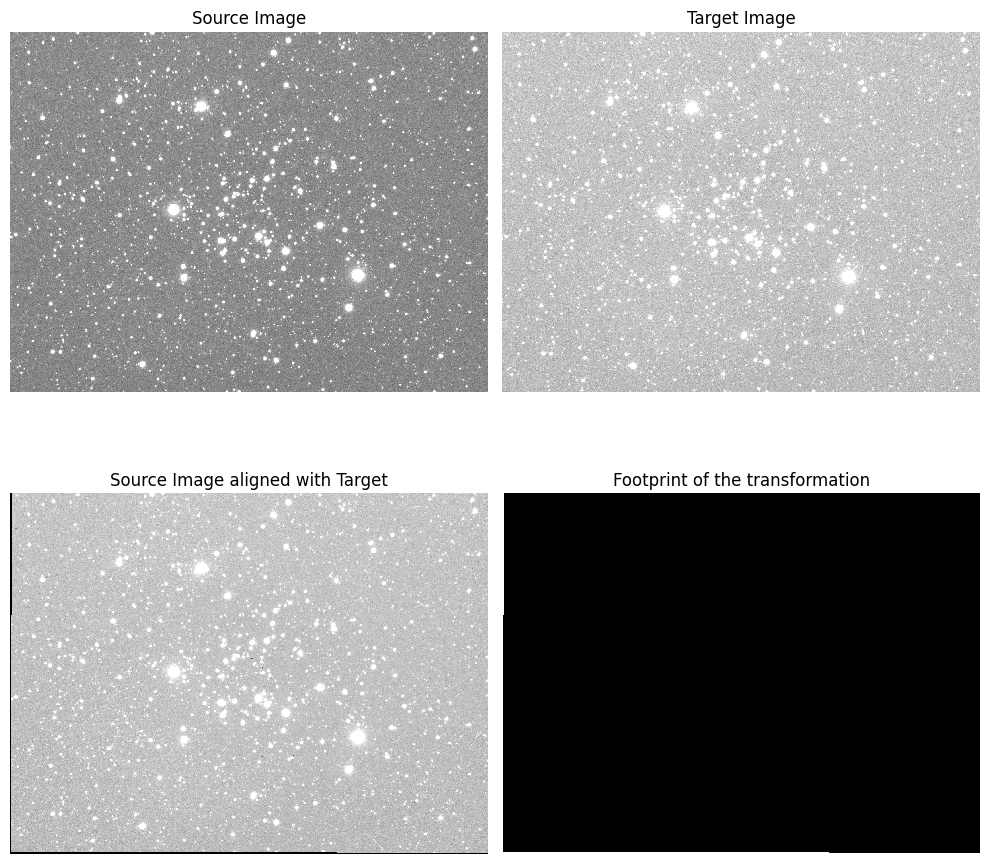

aaproc_NGC_3766_R_00004644.fits
Reference and example image defined
Image alignment determined


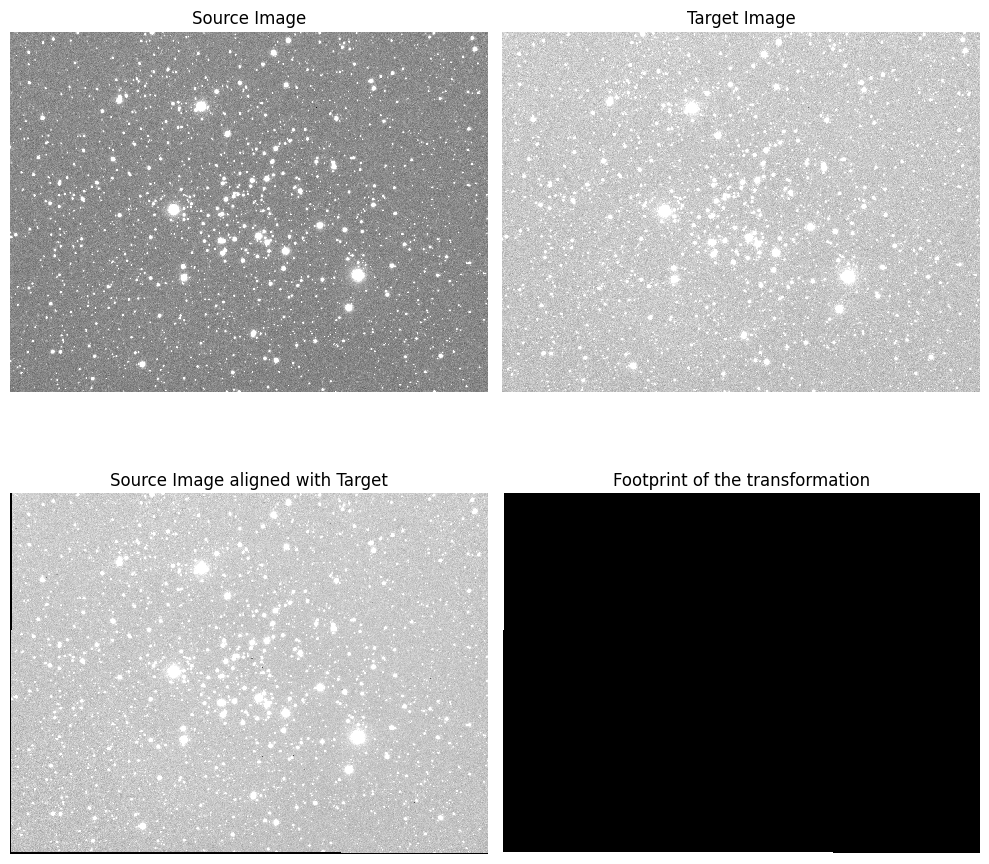

aaproc_NGC_3766_R_00004645.fits


In [21]:
for idx, thisimage in enumerate(scim): # Loop through the numbered list of data

    # Define images to be shifted
    # Plus zero is a quirky fix to an endian issue (old school)
    img_ref=scim[refidx].data+0       # Reference image
    img_example=scim[idx].data+0      # Image to be shifted image
    print('Reference and example image defined')

    # Call astroalign here. It takes the current image, compares it to the reference image, and auto-detects shift.
    img_aligned, footprint = aa.register(img_example, img_ref, detection_sigma=5.0, min_area=9, fill_value=-99999.99)
    print('Image alignment determined')

    # Here we are plotting all our data.
    # Top-left is the reference image
    # Top right is the current target image
    # Bottom left is the target image that has been realigned to the reference image
    # Bottom right is the footprint - which encodes the changes made to the image. You can see white outlines on the image indicating how much it would have been moved by. On days where the objects are in much different locations, you'd be able to see visually in the footprint where the objects were moved from/to.
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes[0, 0].imshow(img_ref, cmap='gray', interpolation='none', origin='lower', vmin=1900, vmax=4100)
    axes[0, 0].axis('off')
    axes[0, 0].set_title("Source Image")

    axes[0, 1].imshow(img_example, cmap='gray', interpolation='none', origin='lower', vmin=1900, vmax=4100)
    axes[0, 1].axis('off')
    axes[0, 1].set_title("Target Image")

    axes[1, 0].imshow(img_aligned, cmap='gray', interpolation='none', origin='lower', vmin=1900, vmax=4100)
    axes[1, 0].axis('off')
    axes[1, 0].set_title("Source Image aligned with Target")

    axes[1, 1].imshow(footprint, cmap='gray', interpolation='none', origin='lower')
    axes[1, 1].axis('off')
    axes[1, 1].set_title("Footprint of the transformation")

    axes[1, 0].axis('off')

    plt.tight_layout()
    plt.show()

    # Save the new aligned data to the files with the new name
    temp=scim[idx]
    temp.data=img_aligned
    temp.meta = scim[idx].meta
    # Write the image to a file using the new name (aaproc prefix)
    print(newname[idx])
    temp.write(newname[idx], overwrite=True)


**Task 22.**  Compare sproc_NGC_3766_R_00004642.fits and aaproc_NGC_3766_R_00004642.fits using ds9, including zooming in to see details of the noise etcetera. How do these images differ from each other? What are pros and cons of using sproc vs aaproc for combined images?

<font color=green>At a surface level they look virtually identical. Upon zooming, we can see some more glaring differences. Firstly, the background is much smoother using aaproc versus sproc. It looks like it was brushed over in photoshop. We can also see obvious dark outlines over very small objects, presumably hot pixels, whereas this is absent. This is a disadvantage of aaproc where it is trying to do subpixel shifts, causing some hot pixels to become more predominant, which is governed by the algorithm it is using. An advantage of aaproc's sub-pixel shifts results in a much more smooth background. Overall, automatic alignment is much more practical for wider-scale aperture photometry for its ease of use for large data sets. Manual alignment is also limited by the user having to move between ds9 and the program and define a small set of target objects to compare, introducing all sorts of errors with hot pixels and saturation issues if they aren't accounted for.

**Task 23.** Don't forget to write your key **conclusions** in this notebook. Remember to have the why before you discuss the how, and then finish with what was found.

<font color=green>The lab demonstrated the alignment and combination of images using aperture photometry. It was done to show us how the astroalign function automatically does this, by writing out in detail how such a program might work to determine alignment differences across images, correct for them, and then combine the images. This is useful because it allows us to take images at different times during the day without worrying so much about having our images under exactly the same position and conditions. It is an essential part of photometry whereby we won't always have access to a super expensive stationary observatory. This allows us to do complex photometry on images taken on our own telescopes much easier.

We found that automatic alignment produced different results than manual (pixel-by-pixel) alignment, showing a much smoother background and much more obvious hot pixels. At scale, automatic alignment algorithms would be much more efficient than manual alignment algorithms due to their ease of use. We can avoid all the intermediate steps of comparing data with ds9, looping through loads of data, comparing stats, and then combining, and instead skip straight to combining. Another disadvantage of manual alignment is that it relies upon the user specifying a few target stars, which has various risks of outliers if those stars are saturated or have hot pixels. Automatic alignment would be able to index all stars at once to reduce this effect.